# 데이터 전처리

1. 결측치없음
2. target : is_fraud
3. 사용자의 집과 가게 위치 거리 (lat, long 이용)
4. first, last 이름 데이터 불필요
5. 시간 변수 2개 trans_date_trans_time, unix_time 1개만 사용해도 되지 않을까..?
6. 상세 주소 데이터 불필요

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [120]:

df = pd.read_csv('fraud.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  491134 non-null  object 
 1   cc_num                 491134 non-null  int64  
 2   merchant               491134 non-null  object 
 3   category               491134 non-null  object 
 4   amt                    491134 non-null  float64
 5   first                  491134 non-null  object 
 6   last                   491134 non-null  object 
 7   gender                 491134 non-null  object 
 8   street                 491134 non-null  object 
 9   city                   491134 non-null  object 
 10  state                  491134 non-null  object 
 11  zip                    491134 non-null  int64  
 12  lat                    491134 non-null  float64
 13  long                   491134 non-null  float64
 14  city_pop               491134 non-nu

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


df['cc_num'].unique()

In [121]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000
mean,3.706013e+17,69.050120,50770.532384,37.931230,-90.495619,1.213922e+05,1.358730e+09,37.930272,-90.495411,0.002533
std,1.260229e+18,160.322867,26854.947965,5.341193,12.990732,3.725751e+05,1.819402e+07,5.372986,13.004100,0.050264
min,5.038744e+11,1.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1.325376e+09,23.655789,-123.345106,0.000000
25%,2.131124e+14,8.960000,28405.000000,33.746700,-97.235100,1.228000e+03,1.343087e+09,33.781388,-96.984814,0.000000
50%,3.531130e+15,42.170000,49628.000000,38.507200,-87.591700,5.760000e+03,1.357257e+09,38.545124,-87.573441,0.000000
75%,4.653879e+15,80.330000,75048.000000,41.520500,-80.731000,5.083500e+04,1.374626e+09,41.624294,-80.685567,0.000000
max,4.956829e+18,25086.940000,99323.000000,48.887800,-69.965600,2.906700e+06,1.388534e+09,49.887523,-68.965624,1.000000


In [122]:
df['is_fraud'].value_counts()

is_fraud
0    489890
1      1244
Name: count, dtype: int64

## 최소 2개 이상의 새로운 피처(변수)를 생성해봅시다.
trans_date_trans_time 변수통해서 날짜, 시간, 요일, 주말여부 변수 생성
dob 데이터를 통해 나이 변수 생성
위도.경도 데이터를 이용해서 개인의 집과 결제된 곳의 거리 변수 생성

In [123]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])


df['date'] = df['trans_date_trans_time'].dt.date
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.dayofweek
df['is_weekend'] = df['day'].apply(lambda x: 1 if x>=5 else 0)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   cc_num                 491134 non-null  int64         
 2   merchant               491134 non-null  object        
 3   category               491134 non-null  object        
 4   amt                    491134 non-null  float64       
 5   first                  491134 non-null  object        
 6   last                   491134 non-null  object        
 7   gender                 491134 non-null  object        
 8   street                 491134 non-null  object        
 9   city                   491134 non-null  object        
 10  state                  491134 non-null  object        
 11  zip                    491134 non-null  int64         
 12  lat                    491134 non-null  floa

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,date,hour,day,is_weekend
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,0,1,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0,2019-01-01,0,1,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0,2019-01-01,0,1,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0,2019-01-01,0,1,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0,2019-01-01,0,1,0


In [124]:
today = pd.to_datetime('today')
df['dob'] = pd.to_datetime(df['dob'])

df['age'] = (today - df['dob']).dt.days // 365
df.info()
df.head()

df.drop(columns = ['dob'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   cc_num                 491134 non-null  int64         
 2   merchant               491134 non-null  object        
 3   category               491134 non-null  object        
 4   amt                    491134 non-null  float64       
 5   first                  491134 non-null  object        
 6   last                   491134 non-null  object        
 7   gender                 491134 non-null  object        
 8   street                 491134 non-null  object        
 9   city                   491134 non-null  object        
 10  state                  491134 non-null  object        
 11  zip                    491134 non-null  int64         
 12  lat                    491134 non-null  floa

In [125]:
lat1 = np.radians(df['lat'])
lon1 = np.radians(df['long'])
lat2 = np.radians(df['merch_lat'])
lon2 = np.radians(df['merch_long'])

# 차이 계산
dlat = lat2 - lat1
dlon = lon2 - lon1

# Haversine 공식
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

# 지구 반지름 (km)
R = 6371  

# 거리 계산
df['distance_km'] = R * c

In [126]:
df.info()
df.head()
df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   cc_num                 491134 non-null  int64         
 2   merchant               491134 non-null  object        
 3   category               491134 non-null  object        
 4   amt                    491134 non-null  float64       
 5   first                  491134 non-null  object        
 6   last                   491134 non-null  object        
 7   gender                 491134 non-null  object        
 8   street                 491134 non-null  object        
 9   city                   491134 non-null  object        
 10  state                  491134 non-null  object        
 11  zip                    491134 non-null  int64         
 12  lat                    491134 non-null  floa

## 사기거래 여부를 예측하는 데 불필요한 컬럼을 제거합니다.
first, last, street, trans_num 컬럼 제거
이름, 상세주소, 거래 번호 


In [127]:
df = df.drop(columns=['first', 'last','street','trans_num'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   cc_num                 491134 non-null  int64         
 2   merchant               491134 non-null  object        
 3   category               491134 non-null  object        
 4   amt                    491134 non-null  float64       
 5   gender                 491134 non-null  object        
 6   city                   491134 non-null  object        
 7   state                  491134 non-null  object        
 8   zip                    491134 non-null  int64         
 9   city_pop               491134 non-null  int64         
 10  job                    491134 non-null  object        
 11  unix_time              491134 non-null  int64         
 12  is_fraud               491134 non-null  int6

## 결측치 확인
info()에서 결측치 없는것 확인했지만, 혹시나해서 isna로 다시 확인

In [128]:
df.isna().mean()

trans_date_trans_time    0.0
cc_num                   0.0
merchant                 0.0
category                 0.0
amt                      0.0
gender                   0.0
city                     0.0
state                    0.0
zip                      0.0
city_pop                 0.0
job                      0.0
unix_time                0.0
is_fraud                 0.0
date                     0.0
hour                     0.0
day                      0.0
is_weekend               0.0
age                      0.0
distance_km              0.0
dtype: float64

# EDA
## 단변량분석

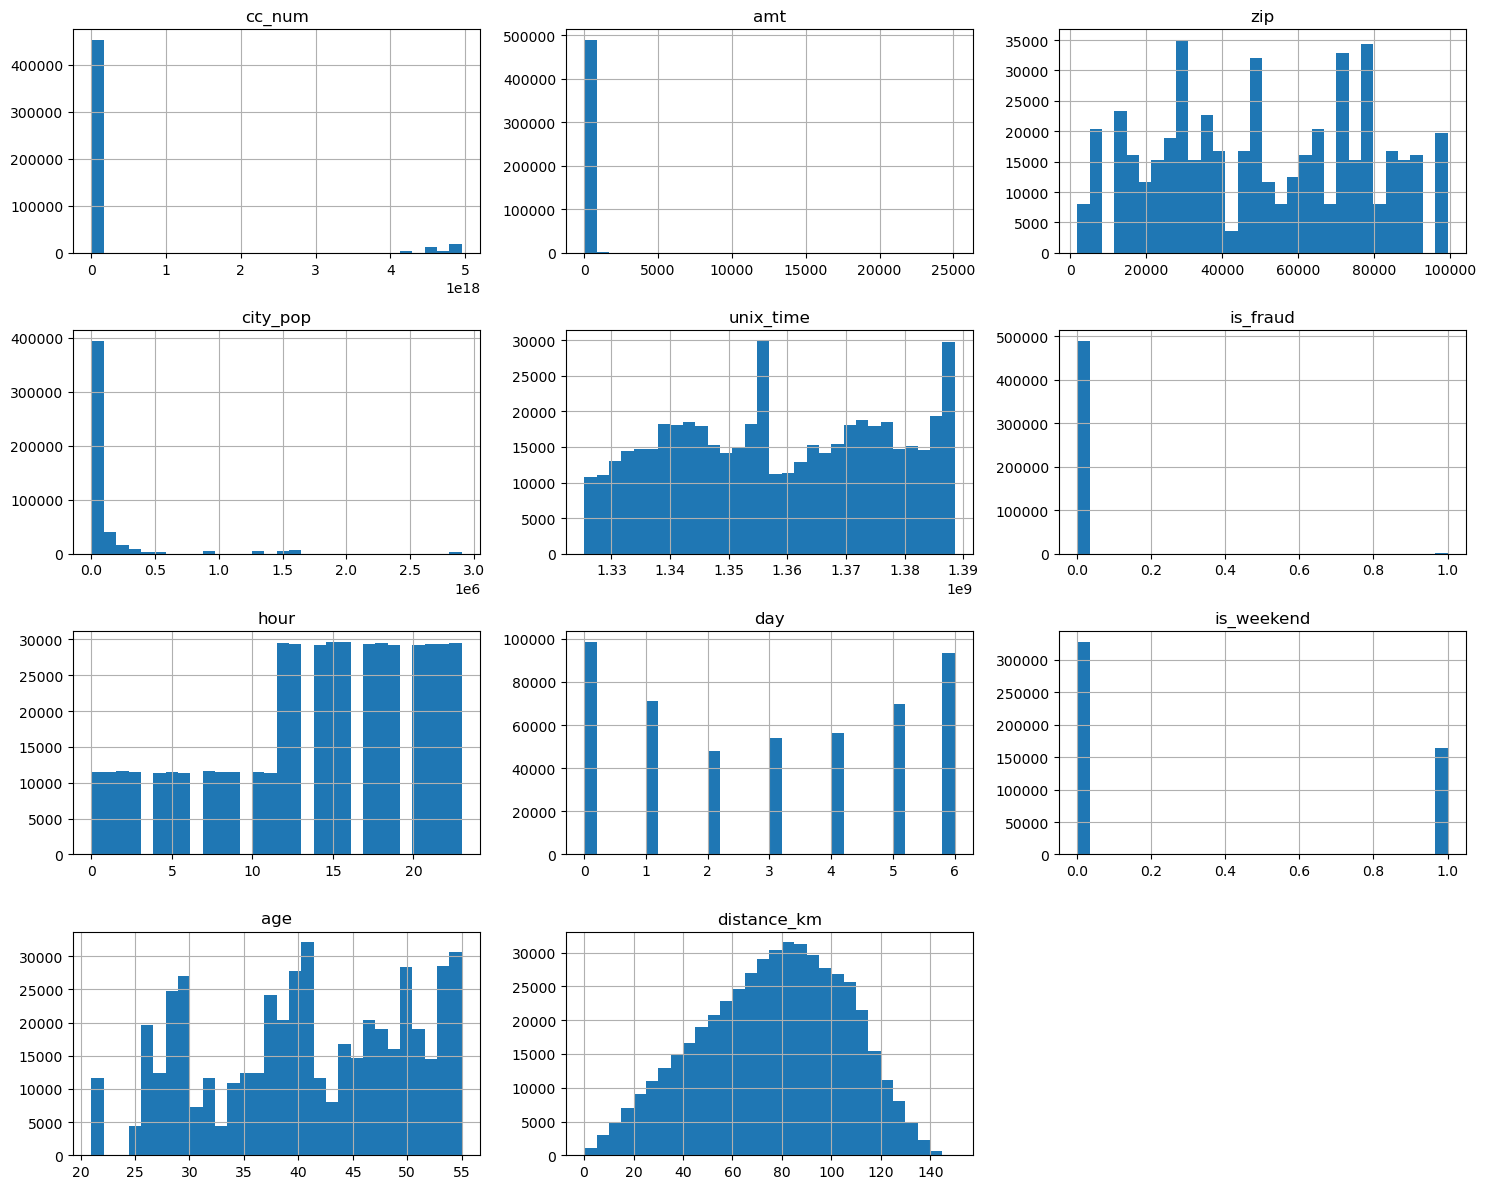

In [129]:
#수치형이지만 경도,위도,cc_num 굳이 분포를 확인할 필요 없을 것 같음
numeric_cols = df.select_dtypes(include=['int64', 'float64','int32']).columns

df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [130]:
card_fraud_count = df.groupby('cc_num')['is_fraud'].sum()
card_fraud_count

card_avg_amt = df.groupby('cc_num')['amt'].mean()
card_avg_amt


cc_num
503874407318           60.253406
567868110212           83.442558
571365235126           59.392974
581686439828           58.578675
630423337322           56.078113
                         ...    
4792627764422477317    84.135134
4797297220948468262    56.313583
4861310130652566408    85.805306
4906628655840914250    54.243453
4956828990005111019    59.858059
Name: amt, Length: 124, dtype: float64

In [131]:
card_avg_amt = df.groupby('cc_num')['amt'].transform('mean')
print(card_avg_amt)
df['amt_ratio'] = df['amt'] / card_avg_amt
df.info()

0         56.078113
1         59.858059
2         87.328067
3         64.317839
4         90.747123
            ...    
491129    87.442772
491130    58.181297
491131    50.452289
491132    88.704297
491133    61.737724
Name: amt, Length: 491134, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   cc_num                 491134 non-null  int64         
 2   merchant               491134 non-null  object        
 3   category               491134 non-null  object        
 4   amt                    491134 non-null  float64       
 5   gender                 491134 non-null  object        
 6   city                   491134 non-null  object        
 7   state                  491134 non-null  object        
 8   zip                   

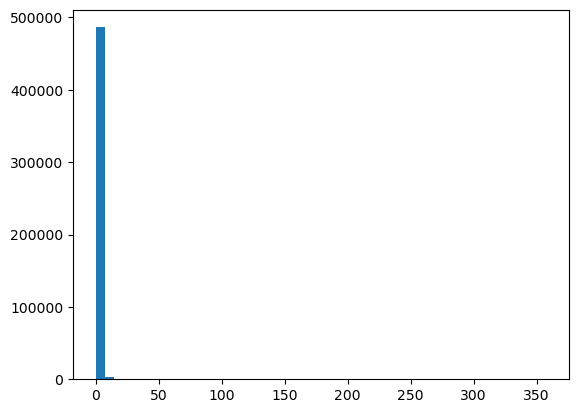

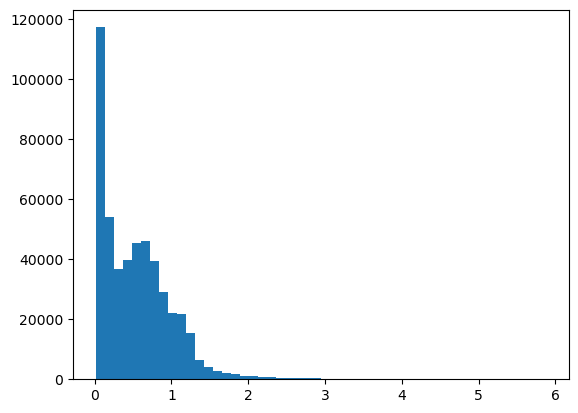

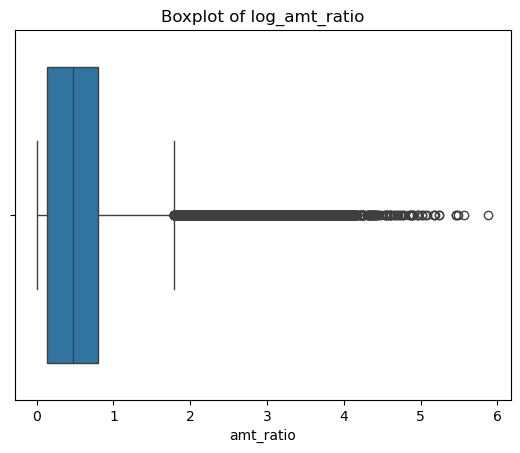

In [132]:
plt.hist(df['amt_ratio'], bins=50)
plt.show()

plt.hist(np.log1p(df['amt_ratio']), bins=50)
plt.show()

sns.boxplot(x=np.log1p(df['amt_ratio']))
plt.title('Boxplot of log_amt_ratio')
plt.show()


### 변수 삭제
cc_num은 카드 고유번호로 삭제. cc_num과 amt를 이용해 만든 amt_ratio 사용.

In [133]:
df.drop(columns='cc_num', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   merchant               491134 non-null  object        
 2   category               491134 non-null  object        
 3   amt                    491134 non-null  float64       
 4   gender                 491134 non-null  object        
 5   city                   491134 non-null  object        
 6   state                  491134 non-null  object        
 7   zip                    491134 non-null  int64         
 8   city_pop               491134 non-null  int64         
 9   job                    491134 non-null  object        
 10  unix_time              491134 non-null  int64         
 11  is_fraud               491134 non-null  int64         
 12  date                   491134 non-null  obje

In [134]:
df.describe()

,trans_date_trans_time,amt,zip,city_pop,unix_time,is_fraud,hour,day,is_weekend,age,distance_km,amt_ratio
count,491134,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000
mean,2020-01-21 13:08:50.095035392,69.050120,50770.532384,1.213922e+05,1.358730e+09,0.002533,14.123087,2.980873,0.332589,40.737587,76.378645,1.000000
min,2019-01-01 00:00:44,1.000000,1843.000000,4.600000e+01,1.325376e+09,0.000000,0.000000,0.000000,0.000000,21.000000,0.123883,0.010731
25%,2019-07-23 23:47:48.249999872,8.960000,28405.000000,1.228000e+03,1.343087e+09,0.000000,10.000000,1.000000,0.000000,33.000000,55.578144,0.144438
50%,2020-01-03 23:43:34.500000,42.170000,49628.000000,5.760000e+03,1.357257e+09,0.000000,15.000000,3.000000,0.000000,41.000000,78.540025,0.606867
75%,2020-07-24 00:30:18.500000,80.330000,75048.000000,5.083500e+04,1.374626e+09,0.000000,19.000000,5.000000,1.000000,49.000000,98.766507,1.223264
max,2020-12-31 23:59:34,25086.940000,99323.000000,2.906700e+06,1.388534e+09,1.000000,23.000000,6.000000,1.000000,55.000000,149.804444,357.764200
std,NaN,160.322867,26854.947965,3.725751e+05,1.819402e+07,0.050264,6.406759,2.209188,0.471141,9.320931,29.169541,2.450662


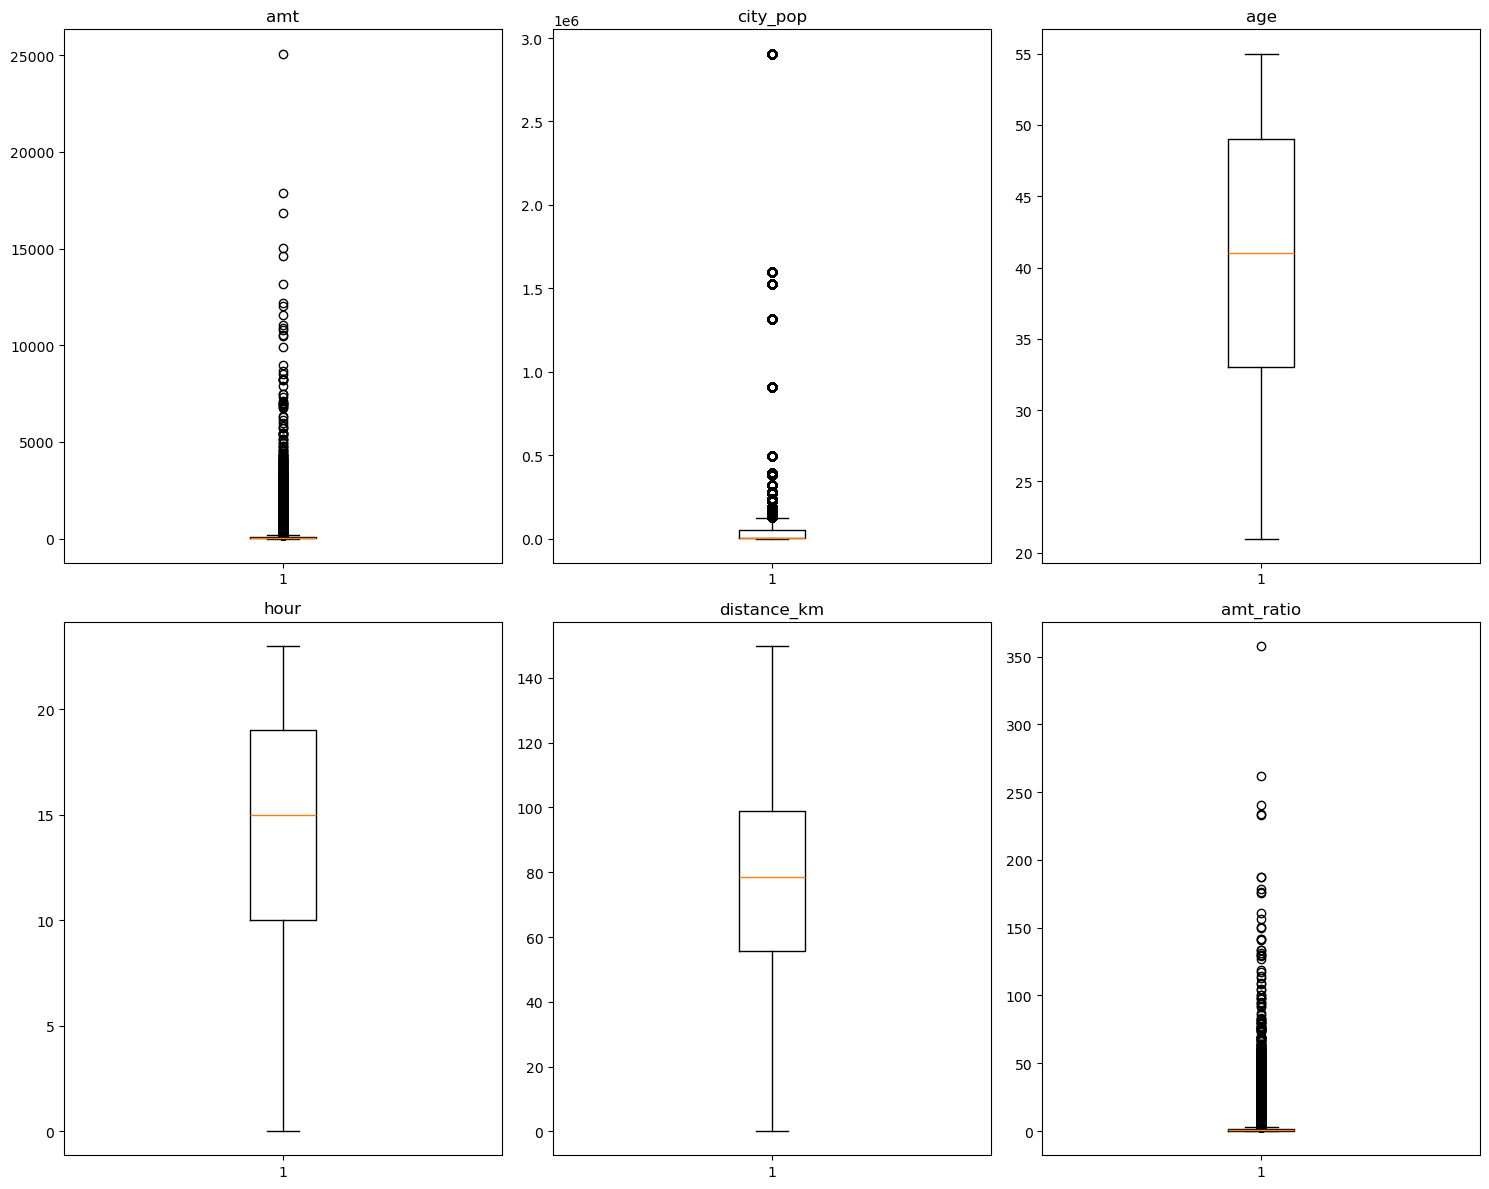

In [135]:
cols = ['amt','city_pop', 'age','hour','distance_km', 'amt_ratio']

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

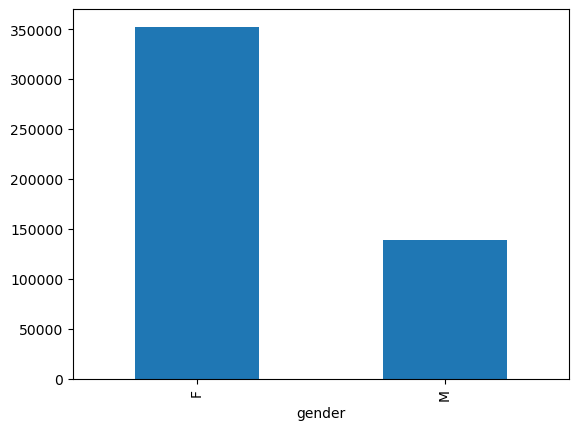

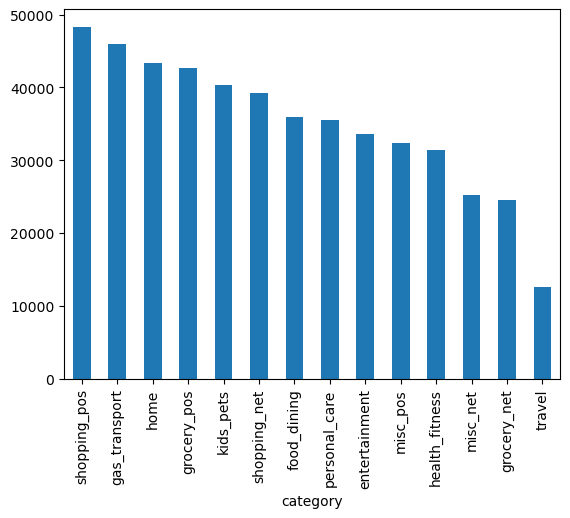

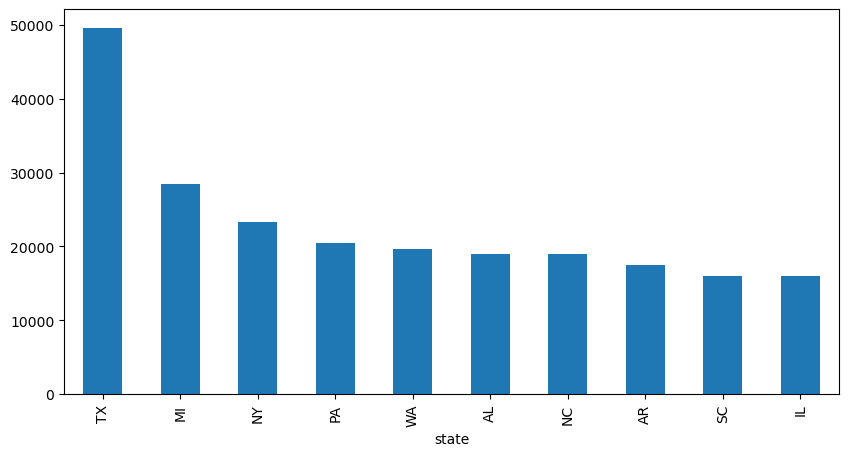

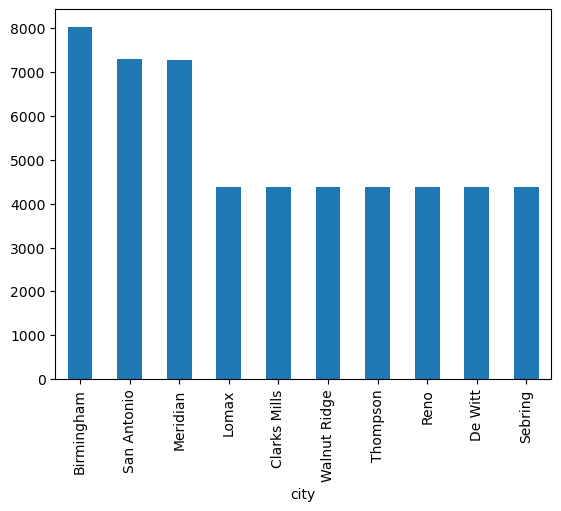

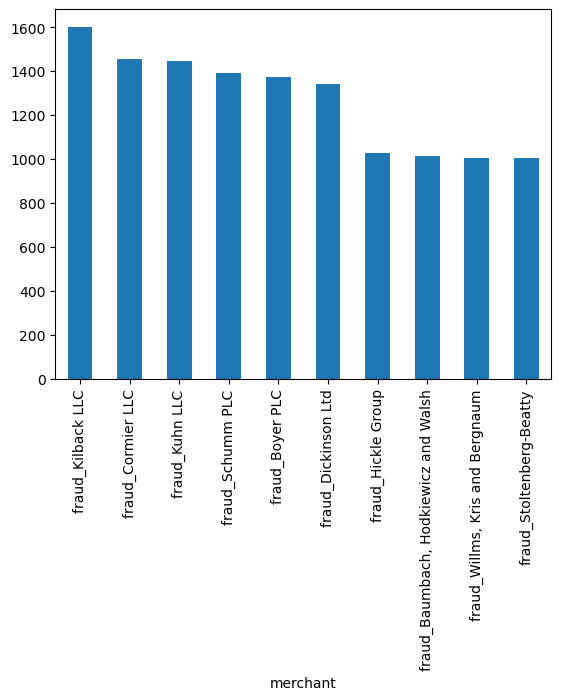

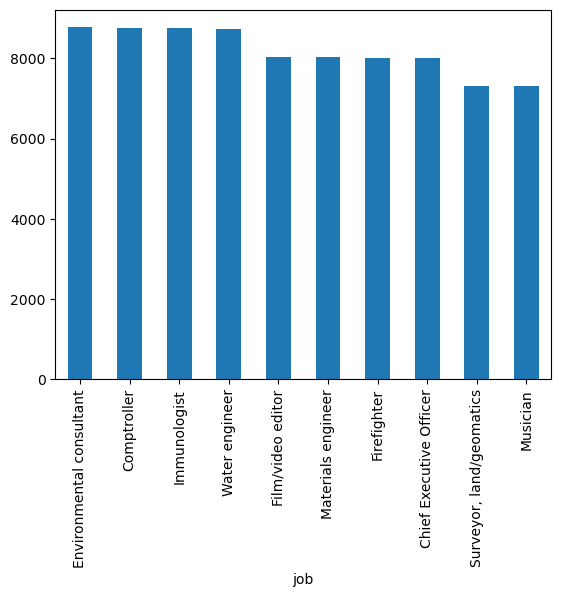

In [136]:
df['gender'].value_counts().plot(kind='bar')
plt.show()

df['category'].value_counts().plot(kind='bar')
plt.show()


df['state'].value_counts().nlargest(10).plot(kind='bar', figsize=(10,5))
plt.show()

df['city'].value_counts().nlargest(10).plot(kind='bar')
plt.show()

df['merchant'].value_counts().nlargest(10).plot(kind='bar')
plt.show()

df['job'].value_counts().nlargest(10).plot(kind='bar')
plt.show()

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   merchant               491134 non-null  object        
 2   category               491134 non-null  object        
 3   amt                    491134 non-null  float64       
 4   gender                 491134 non-null  object        
 5   city                   491134 non-null  object        
 6   state                  491134 non-null  object        
 7   zip                    491134 non-null  int64         
 8   city_pop               491134 non-null  int64         
 9   job                    491134 non-null  object        
 10  unix_time              491134 non-null  int64         
 11  is_fraud               491134 non-null  int64         
 12  date                   491134 non-null  obje

## 이변량 분석
1. 수치형 변수
2. 범주형 변수

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  491134 non-null  datetime64[ns]
 1   merchant               491134 non-null  object        
 2   category               491134 non-null  object        
 3   amt                    491134 non-null  float64       
 4   gender                 491134 non-null  object        
 5   city                   491134 non-null  object        
 6   state                  491134 non-null  object        
 7   zip                    491134 non-null  int64         
 8   city_pop               491134 non-null  int64         
 9   job                    491134 non-null  object        
 10  unix_time              491134 non-null  int64         
 11  is_fraud               491134 non-null  int64         
 12  date                   491134 non-null  obje

In [139]:
num_cols = ['amt','city_pop','unix_time','is_weekend','hour','day','age','distance_km', 'amt_ratio']

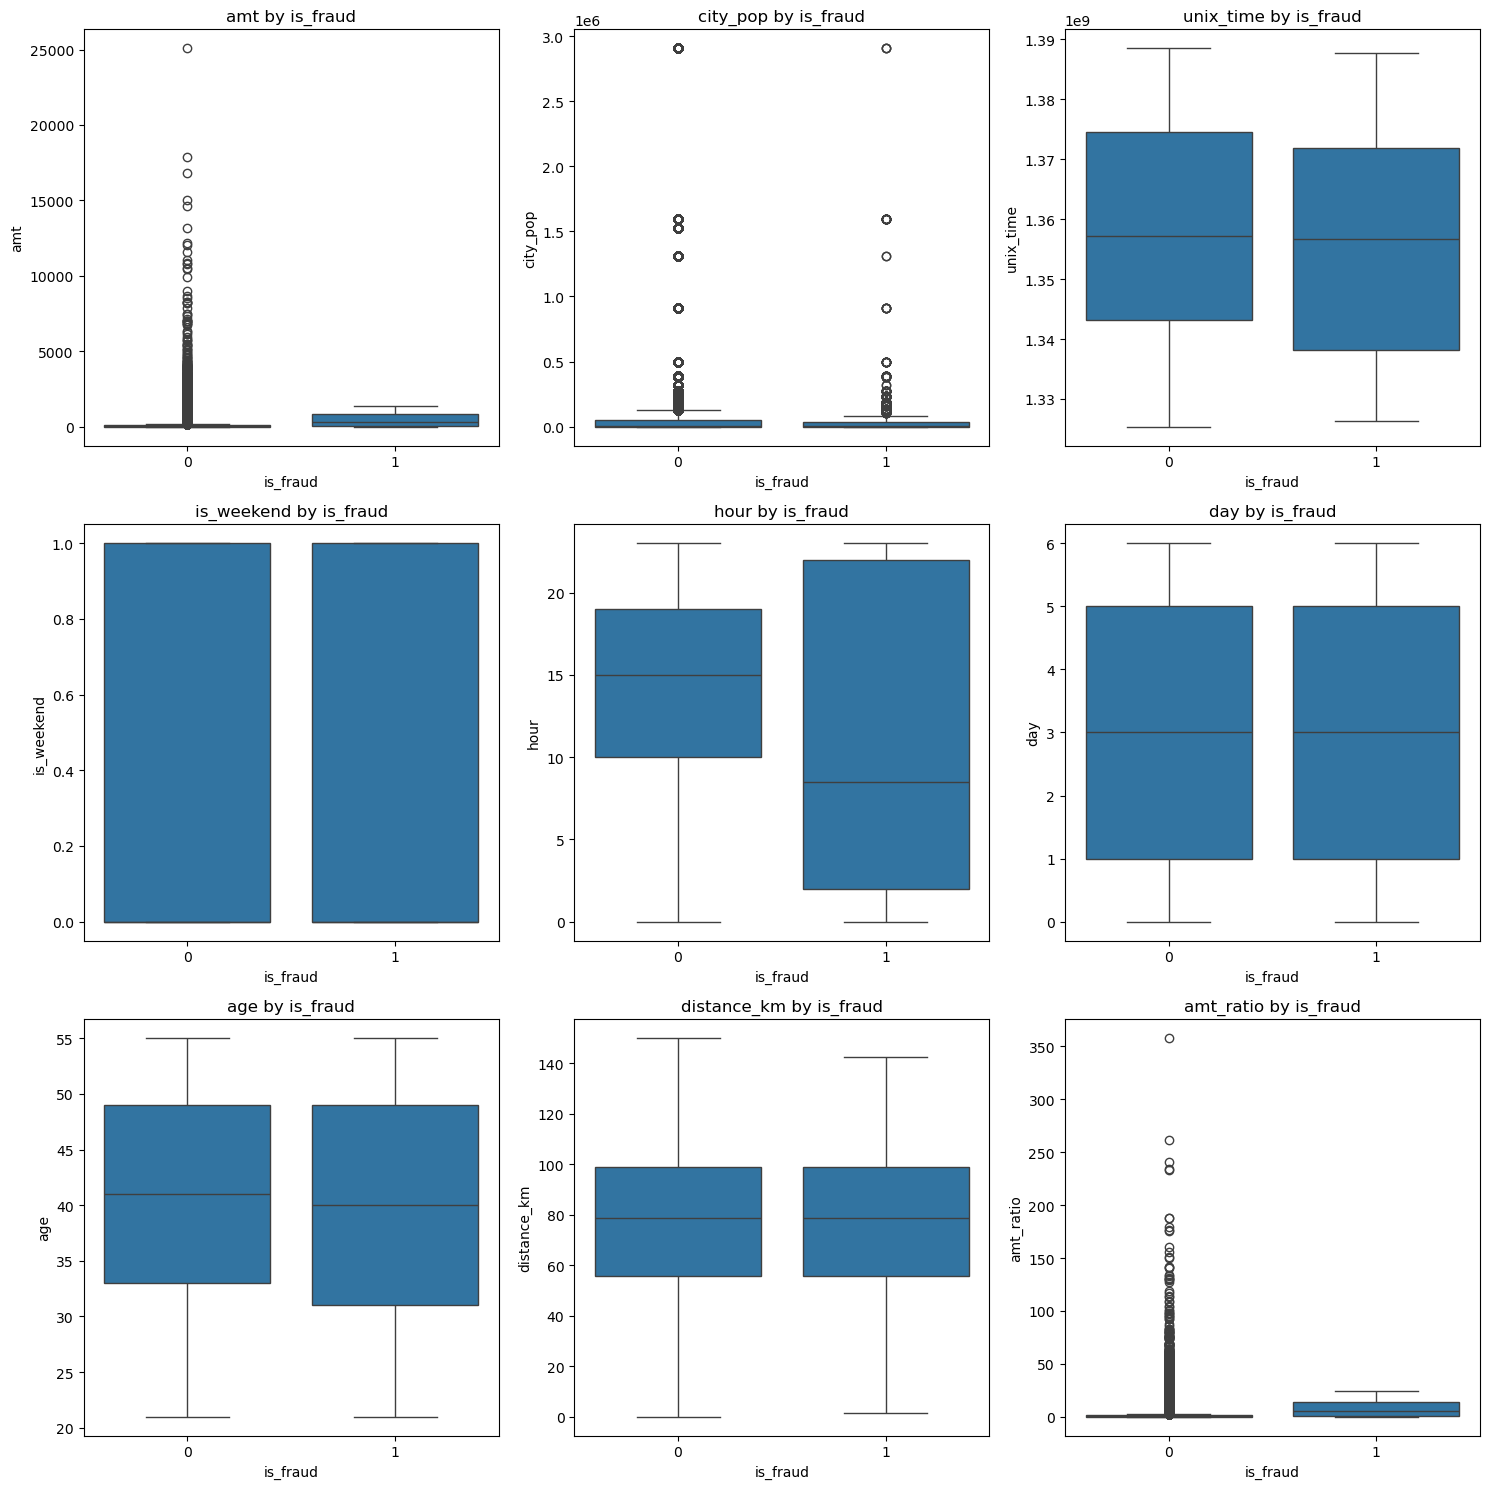

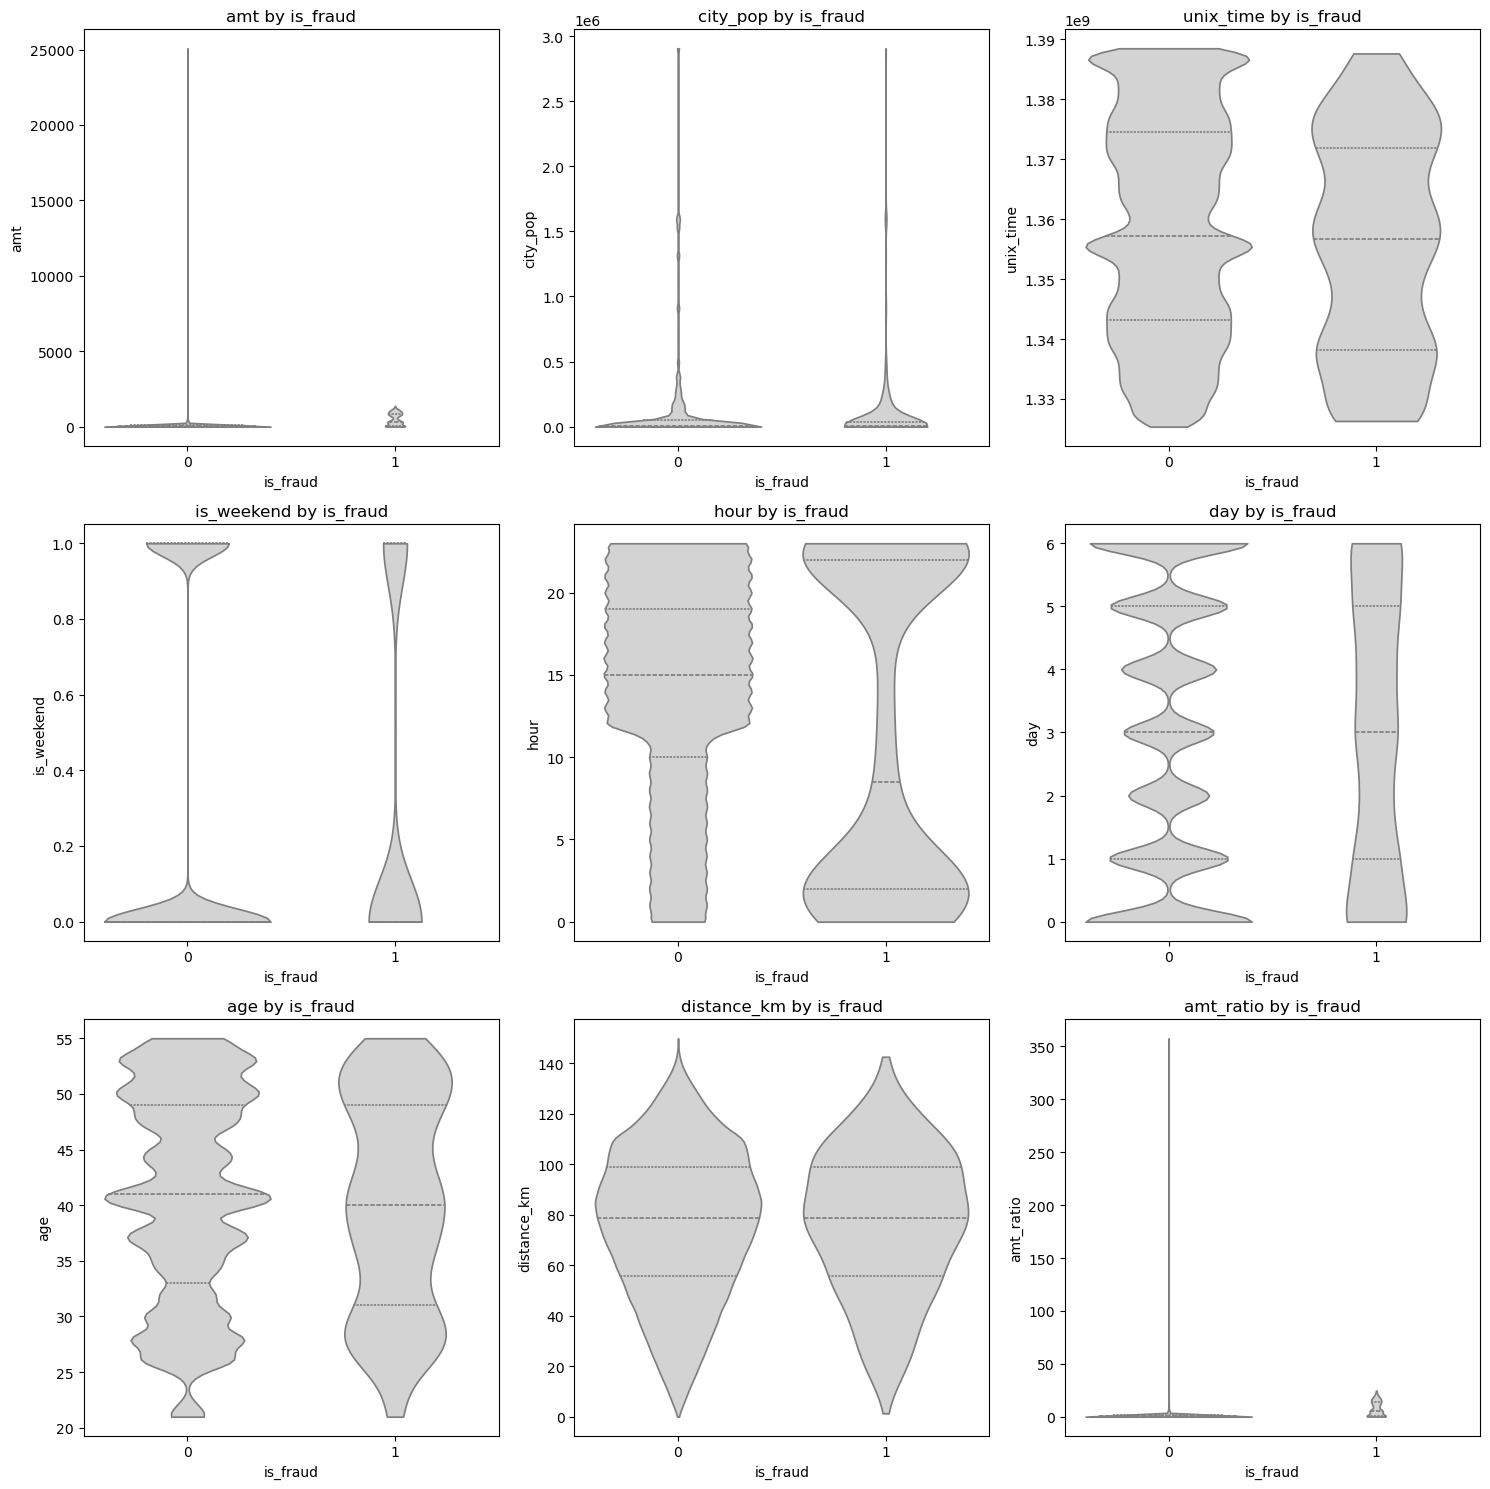

In [140]:
fig, axes = plt.subplots(3,3,figsize = (15,15))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.boxplot(
        x = 'is_fraud',
        y=col,
        data = df,
        ax = axes[i]

    )


    axes[i].set_title(f'{col} by is_fraud')
    axes[i].set_xlabel('is_fraud')

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(3,3, figsize=(15,15))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.violinplot(
        x='is_fraud',
        y=col,
        data=df,
        ax=axes[i],
        inner='quartile',   # 사분위수 표시
        cut=0,               # 범위 밖 꼬리 제거
        color='lightgrey'
    )
    axes[i].set_title(f'{col} by is_fraud')
    axes[i].set_xlabel('is_fraud')


plt.tight_layout()
plt.show()


amt 금액이 정상 거래의 경우 극단값때문에 사기 거래와 비교가 어려움
사기거래의 경우 시간대는 밤~새벽이 많은편


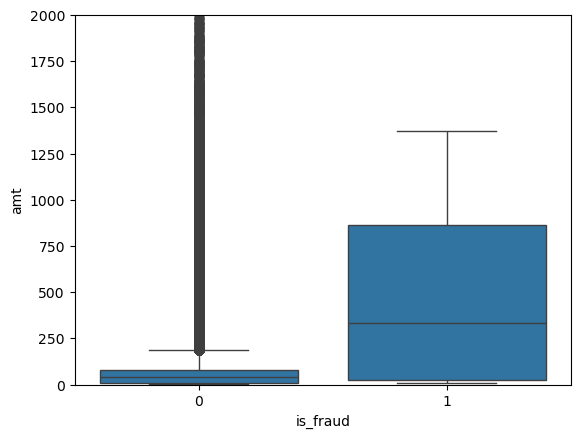

In [141]:
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.ylim(0, 2000)
plt.show()

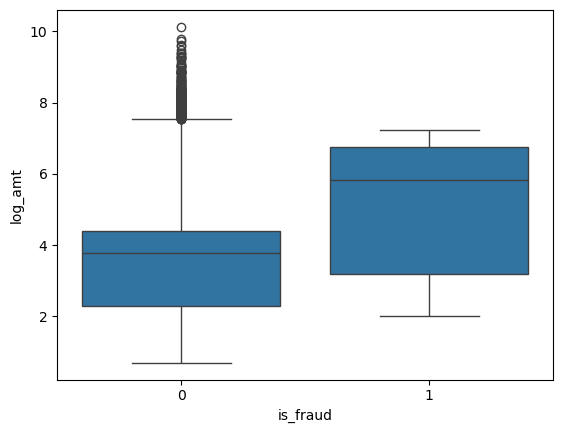

In [142]:
df['log_amt'] = np.log1p(df['amt'])

sns.boxplot(x='is_fraud', y='log_amt', data=df)
plt.show()

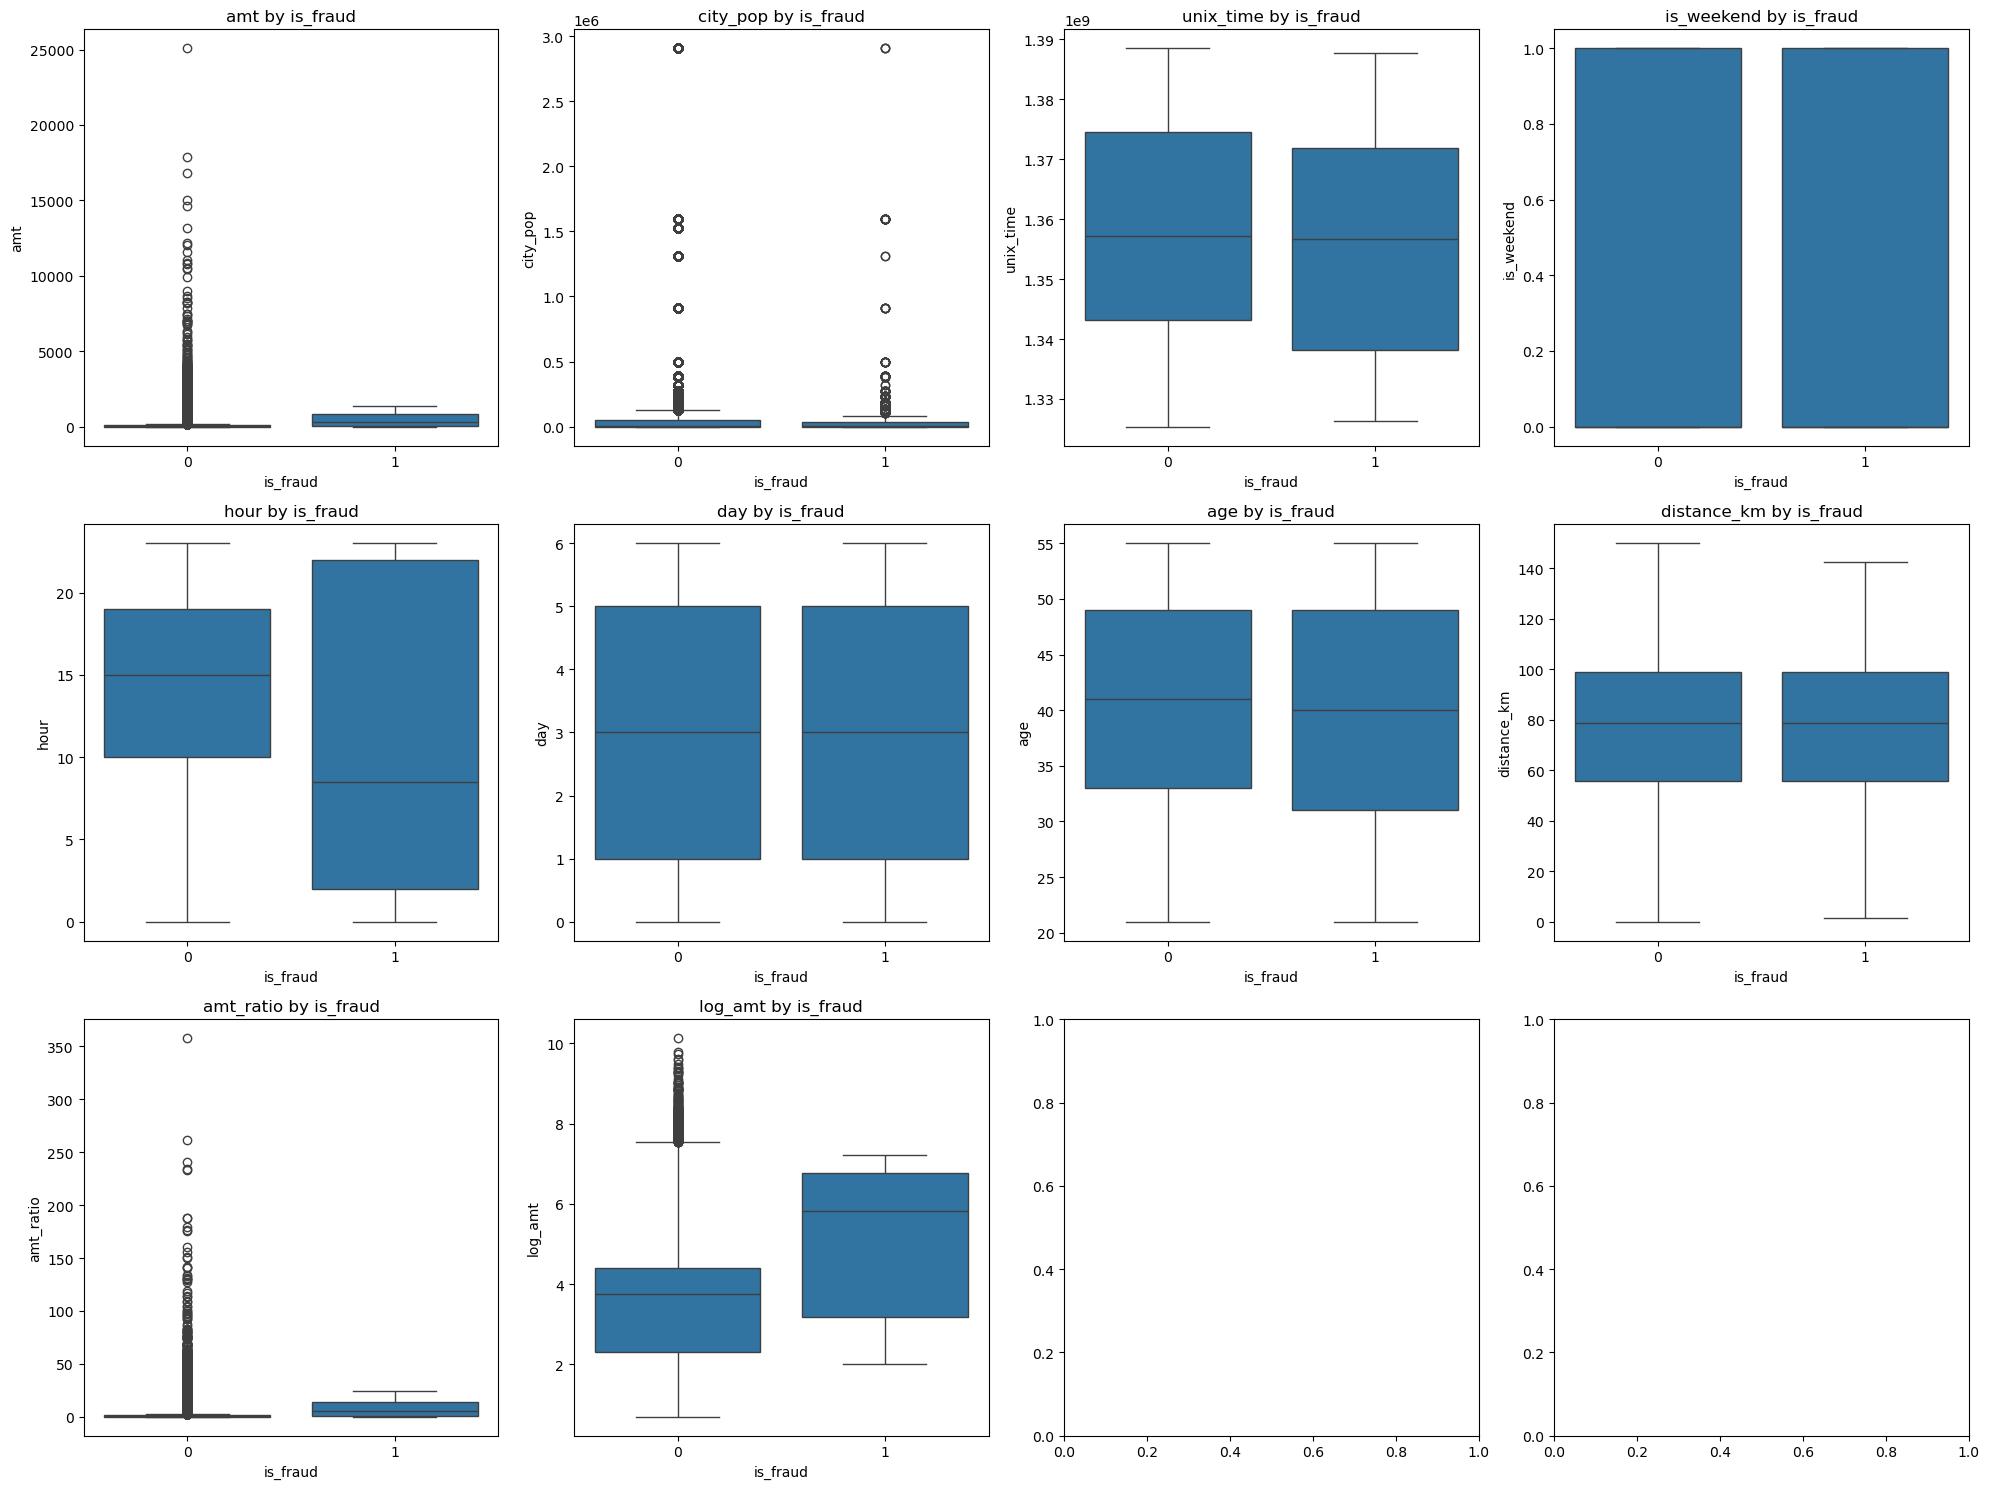

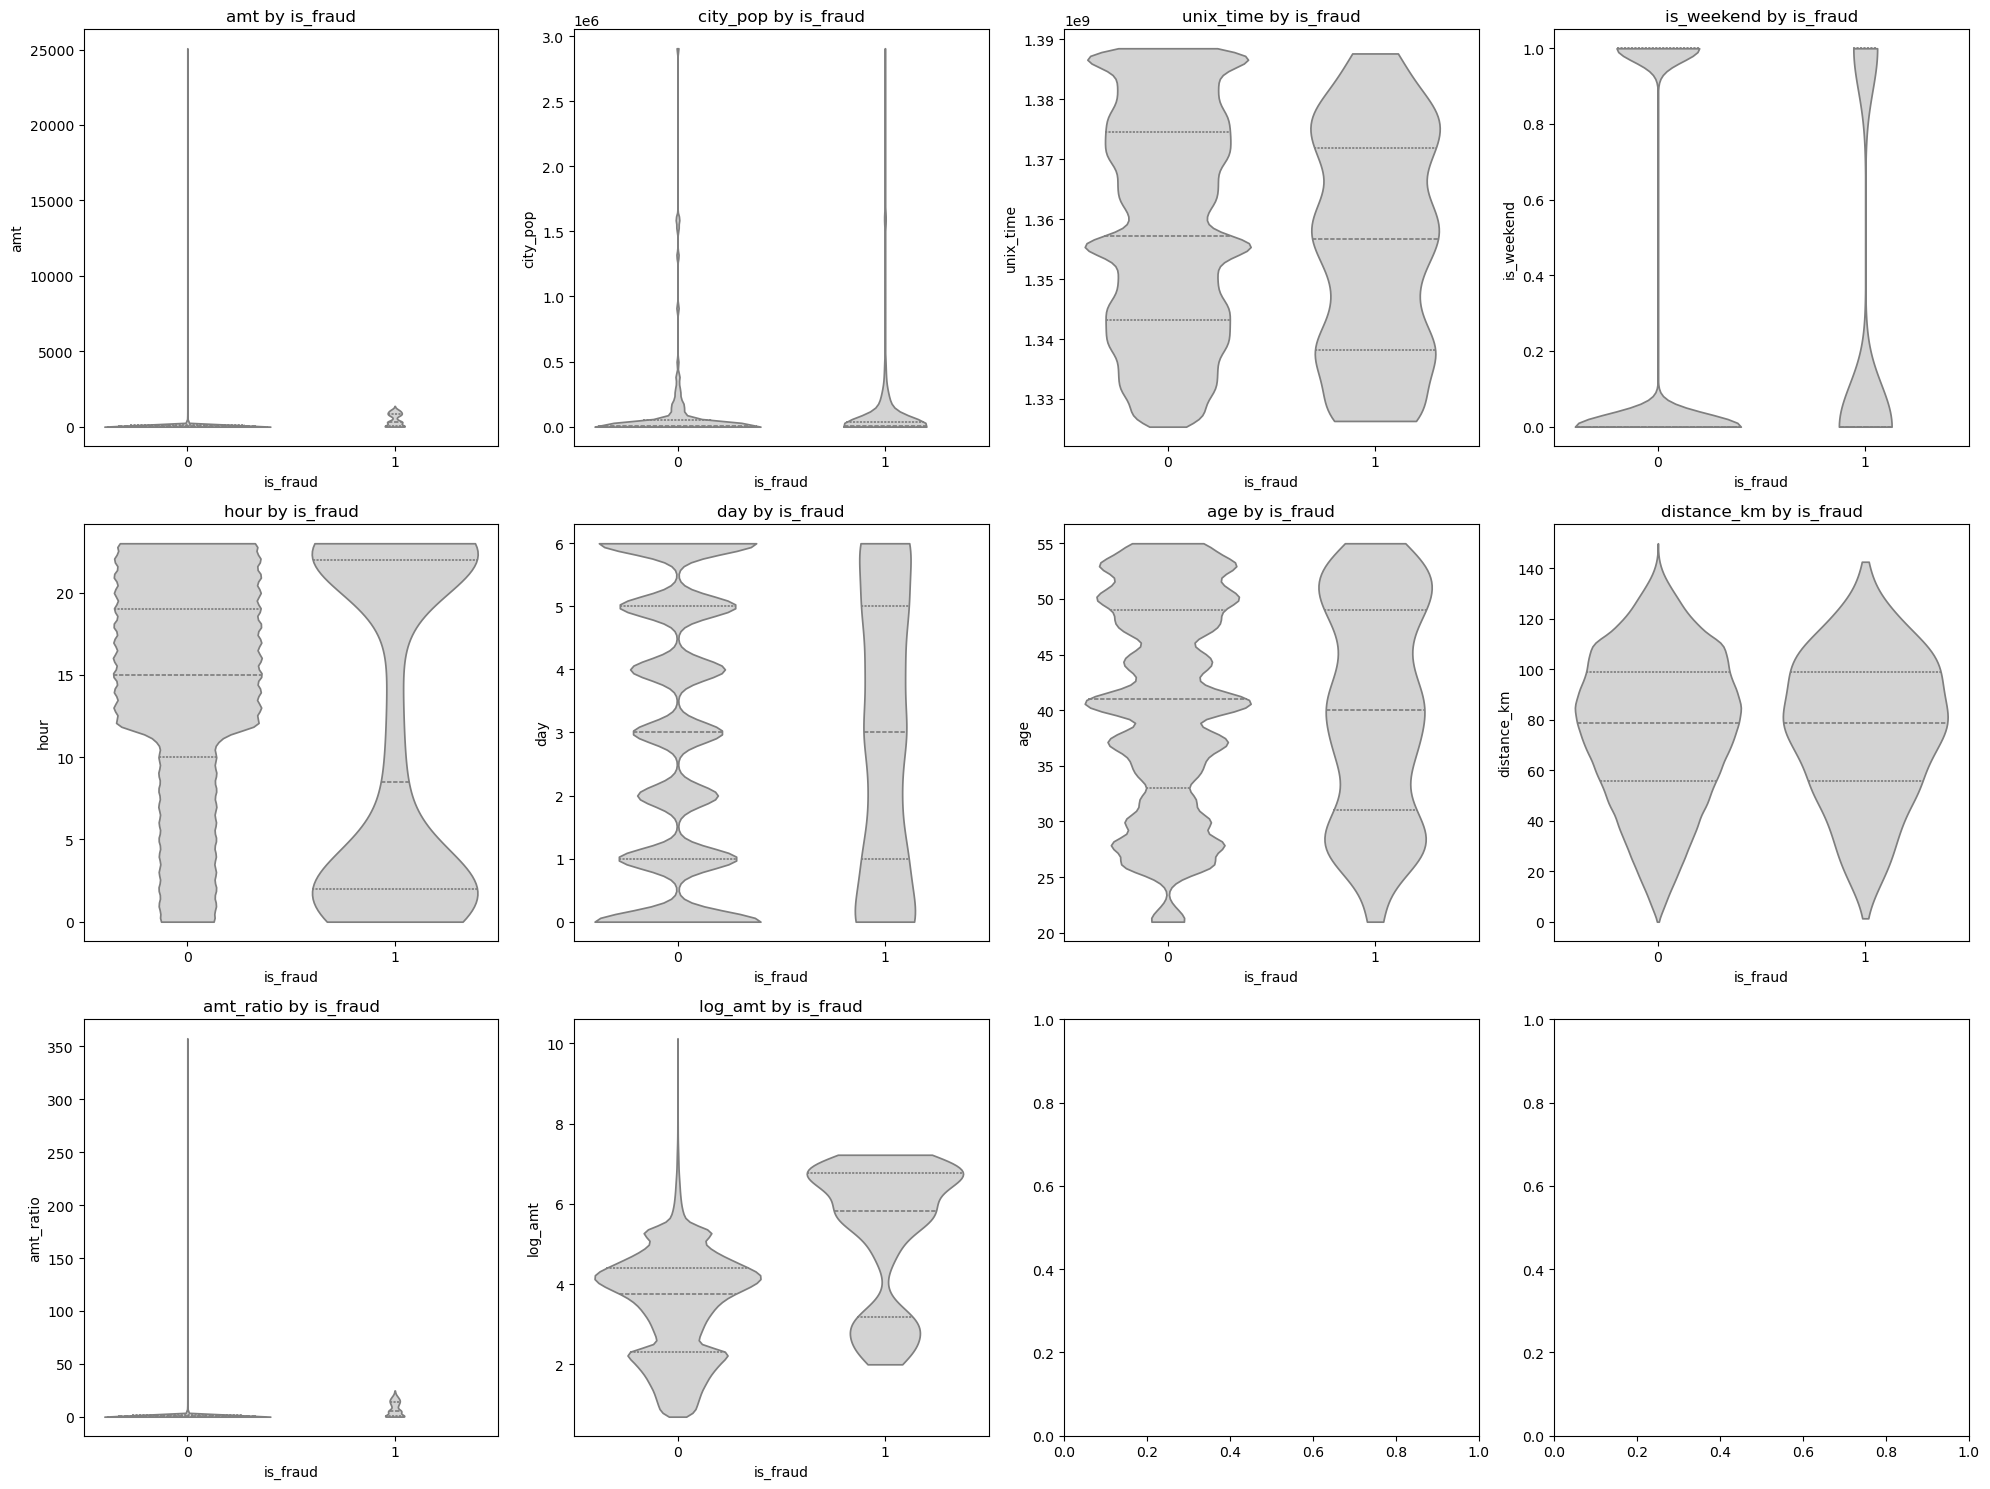

In [143]:
num_cols = ['amt','city_pop','unix_time','is_weekend','hour','day','age','distance_km', 'amt_ratio','log_amt']

fig, axes = plt.subplots(3,4,figsize = (20,15))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.boxplot(
        x = 'is_fraud',
        y=col,
        data = df,
        ax = axes[i]

    )


    axes[i].set_title(f'{col} by is_fraud')
    axes[i].set_xlabel('is_fraud')

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(3,4, figsize=(20,15))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.violinplot(
        x='is_fraud',
        y=col,
        data=df,
        ax=axes[i],
        inner='quartile',   # 사분위수 표시
        cut=0,               # 범위 밖 꼬리 제거
        color='lightgrey'
    )
    axes[i].set_title(f'{col} by is_fraud')
    axes[i].set_xlabel('is_fraud')


plt.tight_layout()
plt.show()


amt값에 로그값을 취하고 다시 비교해봄
이변량분석도 다시 진행함


박스플롯과 바이올린플롯을 확인한 결과
사기거래는 정상거래보다 중~고액 금액에서 발생하는 경향이 있음

사기거래는 정상거래보다 중~고액 금액에서 발생하는 경향이 있음
통계적으로 유의한지 확인하기 위해 Mann–Whitney U test 진행
amt값이 정규분포를 따르지않기때문에 비모수검정 방법 사용

In [144]:
from scipy.stats import mannwhitneyu

fraud = df[df['is_fraud']==1]['amt']
normal = df[df['is_fraud']==0]['amt']

stat, p = mannwhitneyu(fraud, normal, alternative='two-sided')

print("U-statistic:", stat)
print("p-value:", p)

U-statistic: 489603238.5
p-value: 5.2628725781758934e-300


큰 표본에서 p값은 0에 가깝게 나올수있다고 하여
효과 크기를 측정해봄

이것 역시 비모수 효과 크기를 측정함

In [145]:
from itertools import product

fraud = df[df['is_fraud']==1]['amt'].values
normal = df[df['is_fraud']==0]['amt'].values

greater = 0
less = 0

for f in fraud[:1000]:  
    for n in normal[:1000]:
        if f > n:
            greater += 1
        elif f < n:
            less += 1

cliffs_delta = (greater - less) / (greater + less)

print("Cliff's delta:", cliffs_delta)

Cliff's delta: 0.604716932074098


효과크기 0.6이상으로 사기거래금액이 정상거래금액보다 큰 확률이 반대보다 60% 높다는 의미


In [146]:
df['is_fraud'].value_counts()


is_fraud
0    489890
1      1244
Name: count, dtype: int64

In [147]:
def plot_fraud_rate(column):
    stats = df.groupby(column)['is_fraud'].agg(['mean', 'count'])
    
    
    stats = stats.sort_values('mean', ascending=False)
    
    stats['mean'].nlargest(20).plot(kind='bar', figsize=(10,5))
    plt.show()

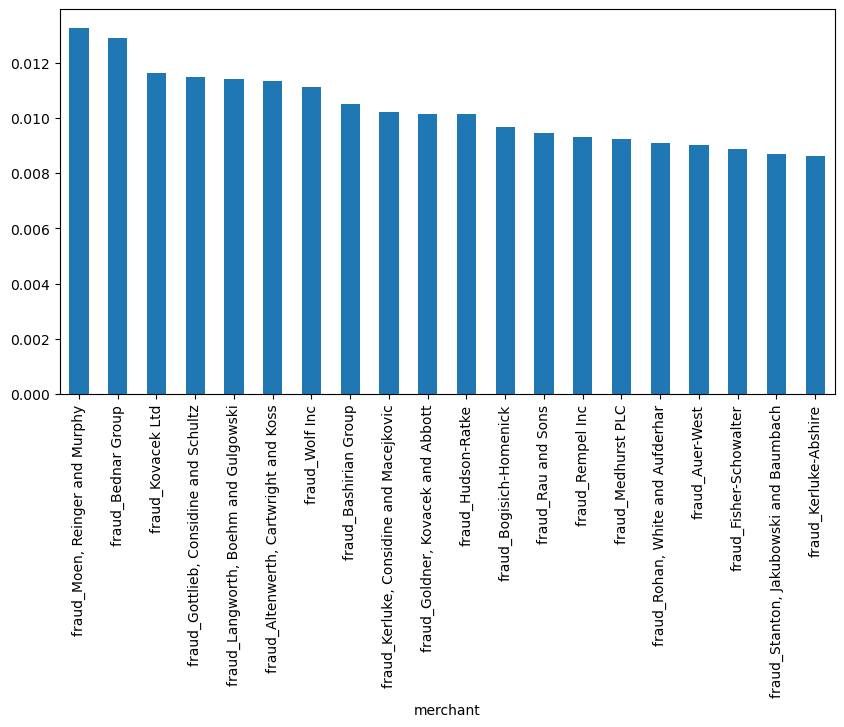

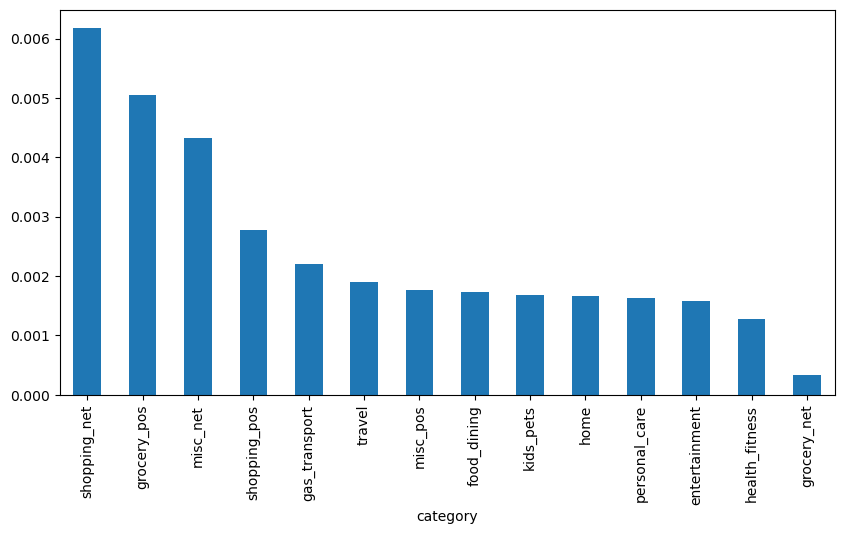

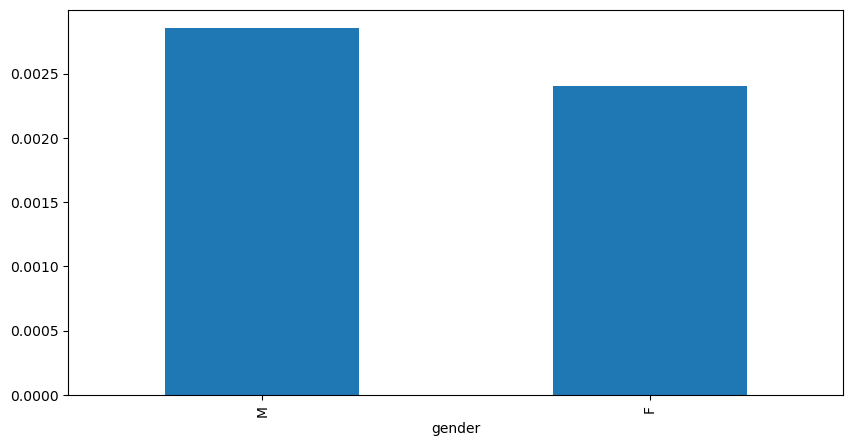

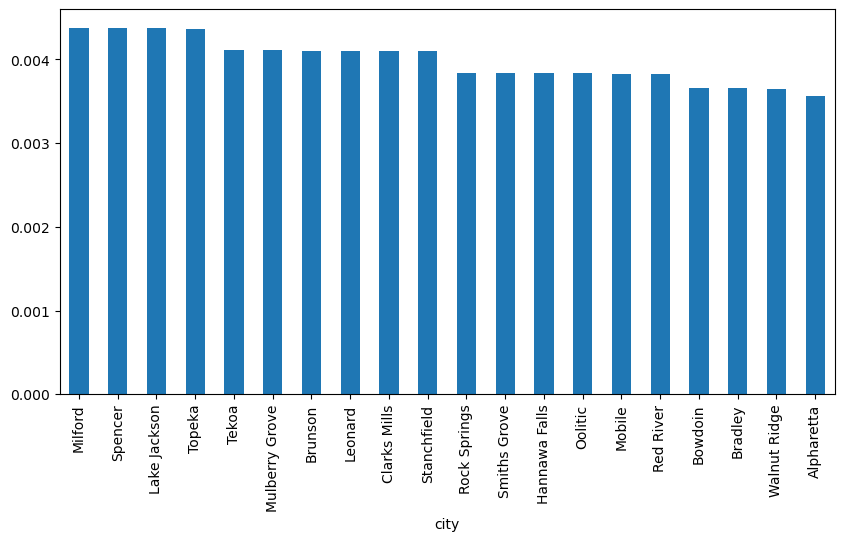

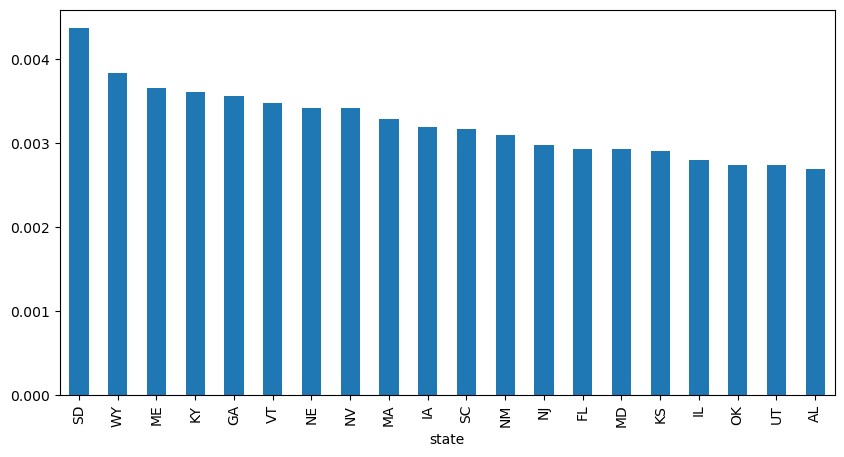

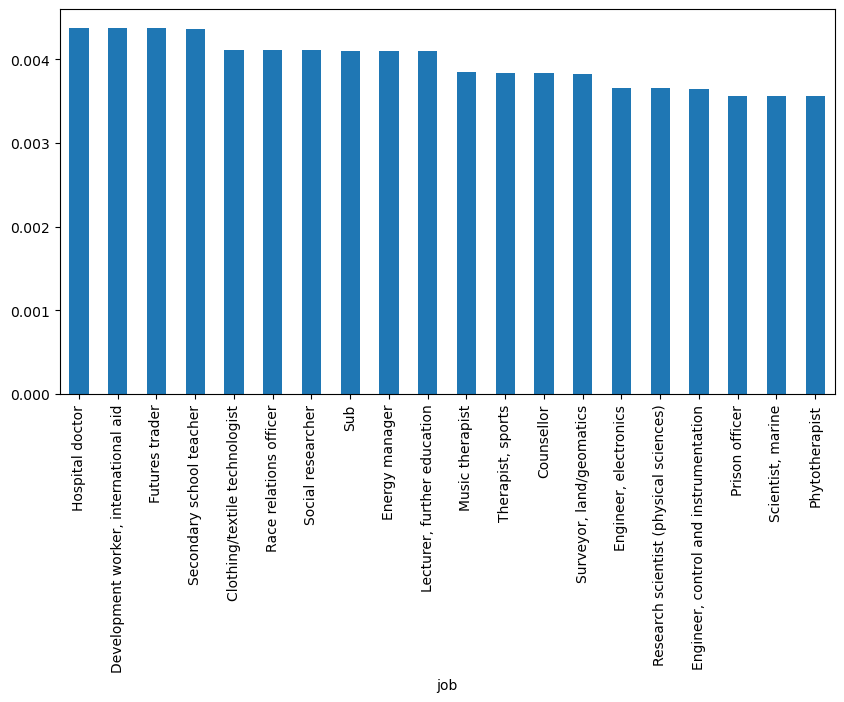

In [148]:
plot_fraud_rate('merchant')
plot_fraud_rate('category')
plot_fraud_rate('gender')
plot_fraud_rate('city')
plot_fraud_rate('state')
plot_fraud_rate('job')



category 에서 shopping_net 사기 비율이 높음을 확인함
온라인 결제 사기가 많을 것으로 예상됨

In [149]:
df['category'].unique()
df = pd.get_dummies(df, columns=['category'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   trans_date_trans_time    491134 non-null  datetime64[ns]
 1   merchant                 491134 non-null  object        
 2   amt                      491134 non-null  float64       
 3   gender                   491134 non-null  object        
 4   city                     491134 non-null  object        
 5   state                    491134 non-null  object        
 6   zip                      491134 non-null  int64         
 7   city_pop                 491134 non-null  int64         
 8   job                      491134 non-null  object        
 9   unix_time                491134 non-null  int64         
 10  is_fraud                 491134 non-null  int64         
 11  date                     491134 non-null  object        
 12  hour            

## 다변량분석
### 상관관계 매트릭스

In [150]:
num_df = df.select_dtypes(include=['int64', 'float64','int32','bool'])
num_df

,amt,zip,city_pop,unix_time,is_fraud,hour,day,is_weekend,age,distance_km,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,107.23,99160,149,1325376044,0,0,1,0,47,30.212176,...,True,False,False,False,False,False,False,False,False,False
1,44.71,7208,124967,1325376754,0,0,1,0,45,84.702120,...,True,False,False,False,False,False,False,False,False,False
2,46.28,7060,71485,1325377036,0,0,1,0,51,67.847742,...,False,False,False,False,False,False,False,False,False,False
3,64.09,48174,31515,1325377215,0,0,1,0,54,22.303906,...,True,False,False,False,False,False,False,False,False,False
4,25.58,70808,378909,1325377421,0,0,1,0,49,79.591943,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491129,134.26,28405,186140,1388534208,0,23,3,0,43,98.027030,...,False,False,True,False,False,False,False,False,False,False
491130,25.49,29819,1523,1388534217,0,23,3,0,41,127.382373,...,False,False,False,False,False,False,False,False,True,False
491131,111.84,77566,28739,1388534349,0,23,3,0,26,100.074420,...,False,False,False,True,False,False,False,False,False,False
491132,86.88,99323,3684,1388534355,0,23,3,0,44,80.759302,...,False,False,False,True,False,False,False,False,False,False


In [151]:
corr_matrix = num_df.corr()
corr_matrix

,amt,zip,city_pop,unix_time,is_fraud,hour,day,is_weekend,age,distance_km,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
amt,1.000000,1.059374e-02,1.351148e-02,-0.003087,0.128526,-0.053056,0.001134,0.001069,2.310930e-02,-1.286407e-03,...,0.111106,-0.023690,-0.026139,-0.026127,1.895348e-02,0.005495,-0.040912,0.022732,0.028548,-0.005789
zip,0.010594,1.000000e+00,1.190944e-01,0.002153,-0.003005,0.000115,-0.001874,-0.002804,5.451028e-02,8.155438e-03,...,0.000708,-0.001203,0.001215,0.003905,-6.000244e-04,0.000098,0.005560,0.007267,0.003309,-0.003847
city_pop,0.013511,1.190944e-01,1.000000e+00,-0.001749,-0.005630,-0.000919,-0.000876,0.002138,3.893401e-02,1.810863e-02,...,0.003672,0.002267,0.003634,0.002352,-1.564979e-03,-0.001155,-0.004104,0.009490,0.008831,0.001553
unix_time,-0.003087,2.152760e-03,-1.749111e-03,1.000000,-0.008156,0.003084,-0.080413,-0.072734,-1.009928e-02,-5.118236e-04,...,-0.001737,0.000834,-0.001811,0.001526,1.746050e-03,-0.000191,0.000383,0.000805,0.000360,0.001695
is_fraud,0.128526,-3.005028e-03,-5.630389e-03,-0.008156,1.000000,-0.020113,-0.001562,-0.002299,-4.313577e-03,6.654250e-04,...,0.015494,-0.006551,-0.005395,-0.005028,8.306461e-03,-0.004094,-0.004997,0.021344,0.001570,-0.002040
hour,-0.053056,1.153317e-04,-9.192288e-04,0.003084,-0.020113,1.000000,0.000054,0.002717,-5.067862e-02,-1.569191e-03,...,-0.392184,0.137790,0.164066,0.156823,-1.658361e-01,-0.008393,0.148008,0.152760,0.173476,0.084870
day,0.001134,-1.874227e-03,-8.757352e-04,-0.080413,-0.001562,0.000054,1.000000,0.828102,-1.424527e-02,7.591272e-04,...,-0.001046,-0.000422,-0.001345,-0.000740,4.496766e-04,0.005345,-0.001451,-0.000638,-0.001167,0.000195
is_weekend,0.001069,-2.804166e-03,2.137777e-03,-0.072734,-0.002299,0.002717,0.828102,1.000000,-3.691854e-02,1.130516e-03,...,-0.003909,0.001584,-0.004242,-0.000956,-2.992329e-04,0.006762,-0.001322,0.000709,-0.001147,0.001704
age,0.023109,5.451028e-02,3.893401e-02,-0.010099,-0.004314,-0.050679,-0.014245,-0.036919,1.000000e+00,3.753624e-03,...,0.053393,-0.015073,0.048316,0.014255,-1.748581e-02,-0.006059,0.003546,0.003352,0.009584,-0.013946
distance_km,-0.001286,8.155438e-03,1.810863e-02,-0.000512,0.000665,-0.001569,0.000759,0.001131,3.753624e-03,1.000000e+00,...,0.001169,-0.001449,-0.001158,-0.001570,-7.887395e-07,0.000751,0.001418,0.002711,-0.000013,0.001459


### 히트맵

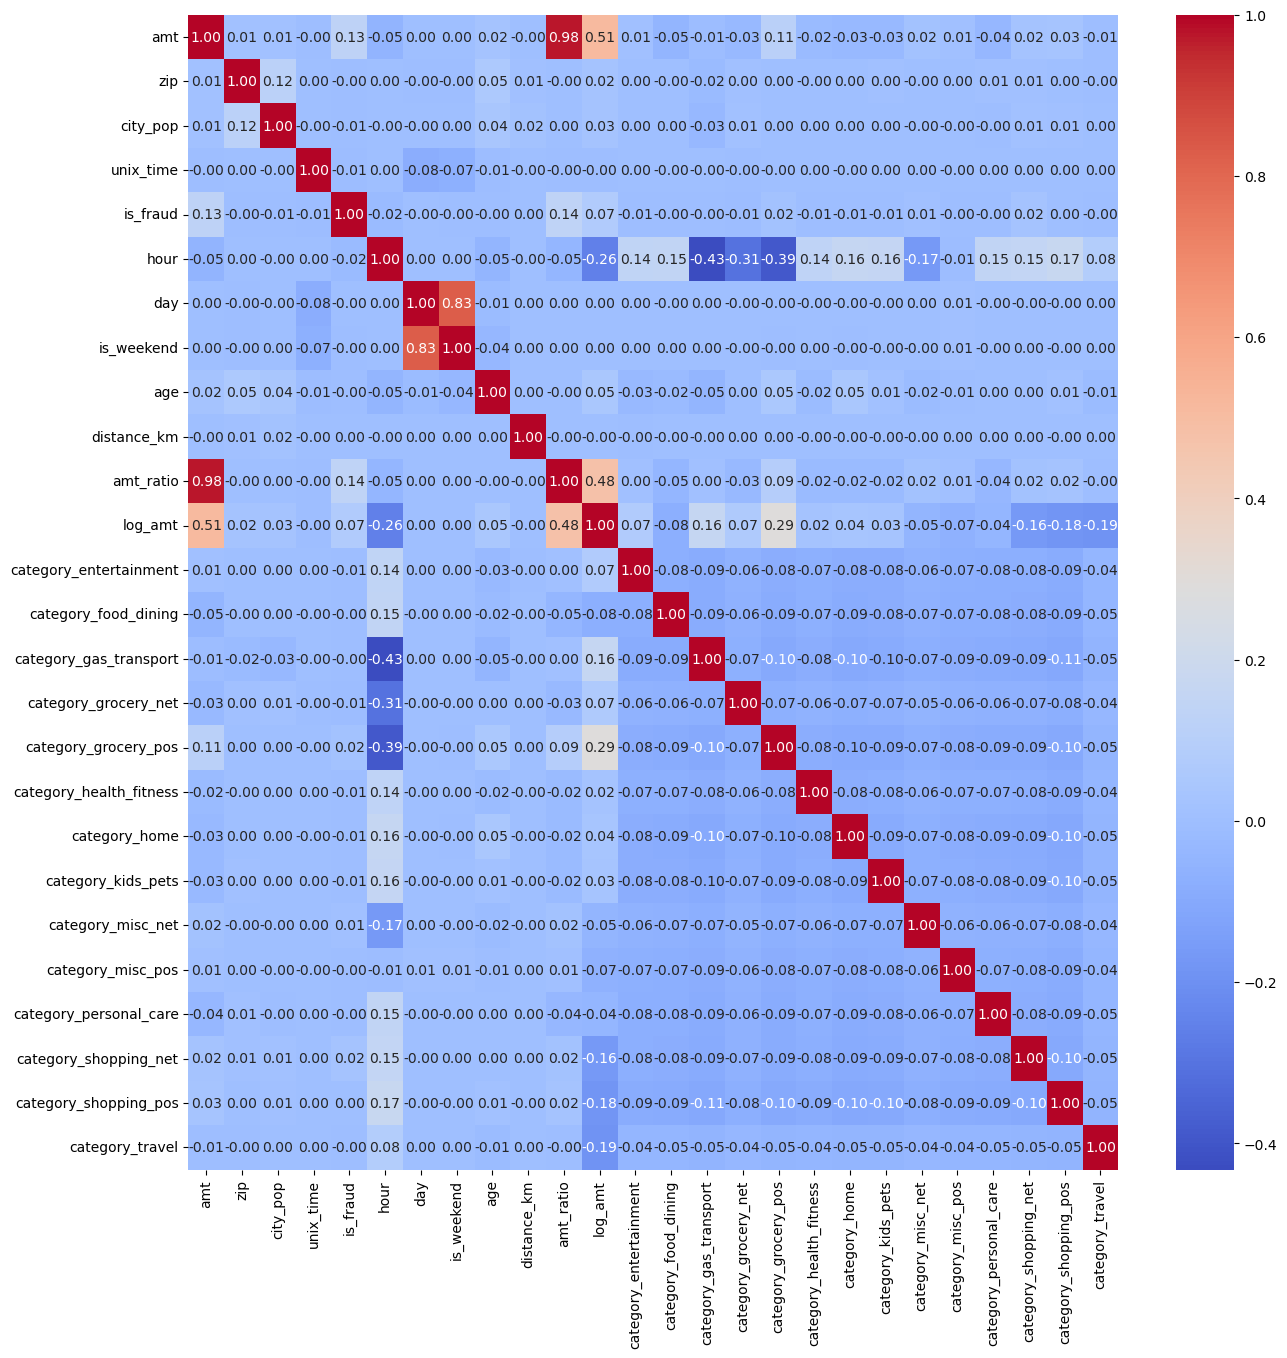

In [152]:
plt.figure(figsize=(15,15))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = 'coolwarm'

)

plt.show()

is_weekend와 day 강한 상관관계
다중공선성 발생 가능하기에 둘 중 한개만 사용.
주말 여부에서 큰 유의미한 값을 발견하지 못했기도하고 day 값이 있으므로 drop

특정 카테고리와 hour의 상관관계

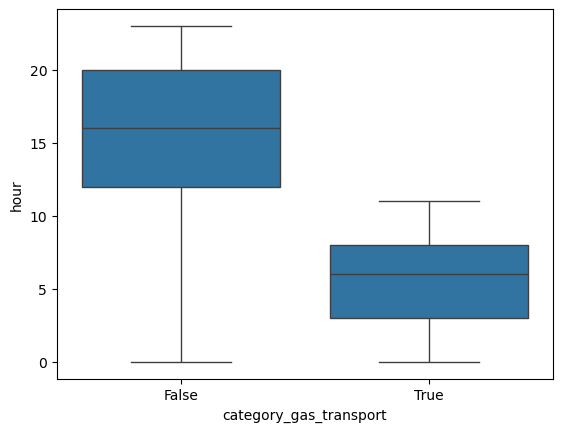

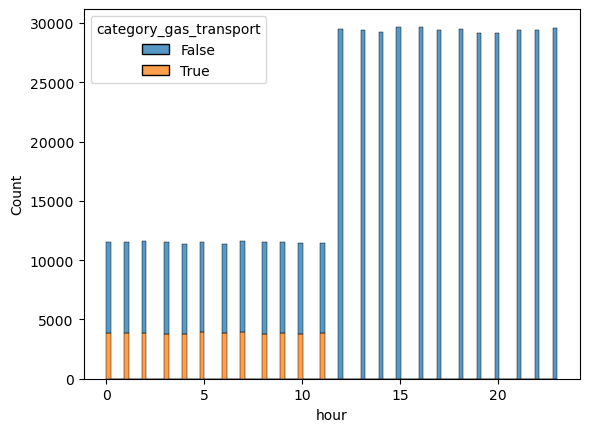

In [153]:
sns.boxplot(x='category_gas_transport', y='hour', data=df)
plt.show()

sns.histplot(data=df, x='hour', hue='category_gas_transport', multiple='stack')
plt.show()

In [154]:
df.drop(columns='is_weekend', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   trans_date_trans_time    491134 non-null  datetime64[ns]
 1   merchant                 491134 non-null  object        
 2   amt                      491134 non-null  float64       
 3   gender                   491134 non-null  object        
 4   city                     491134 non-null  object        
 5   state                    491134 non-null  object        
 6   zip                      491134 non-null  int64         
 7   city_pop                 491134 non-null  int64         
 8   job                      491134 non-null  object        
 9   unix_time                491134 non-null  int64         
 10  is_fraud                 491134 non-null  int64         
 11  date                     491134 non-null  object        
 12  hour            

# eda에서 만든 파생 변수 삭제
amt_ratio값의 경우 해당 카드의 거래금액 평균을 이용해서 비율을 계산했기에 미래 값이 들어가있어서
모델 학습에 적합하지 않기에 삭제


In [156]:
df.drop(columns='amt_ratio', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   trans_date_trans_time    491134 non-null  datetime64[ns]
 1   merchant                 491134 non-null  object        
 2   amt                      491134 non-null  float64       
 3   gender                   491134 non-null  object        
 4   city                     491134 non-null  object        
 5   state                    491134 non-null  object        
 6   zip                      491134 non-null  int64         
 7   city_pop                 491134 non-null  int64         
 8   job                      491134 non-null  object        
 9   unix_time                491134 non-null  int64         
 10  is_fraud                 491134 non-null  int64         
 11  date                     491134 non-null  object        
 12  hour            

가설1. 사기 거래의 경우 정상거래의 비해 중~고액금액 결제가 많다
가설2. 온라인 결제나 식료품점,쇼핑몰 포스에서 사기 거래가 많다.
